# Modelaje y presentación de resultados.

Aquí haremos un showcase de los resultados. Usamos Programación Orientada a Objetos para dejar acomodados de forma más ordenada los distintos modelos y resultados. Al final haremos una tabla comparativa.

Primero, cargaremos nuestra clase `compareModels` la cual tiene los métodos para hacer la predicción. También en dicha clase se encuentra los métodos para hacer `GridSearchCV`. Se encuentran métodos para hacer gráficos también.

In [1]:
import sys
sys.path.insert(0, '..')     
from modelaje import compareModels

comparacion = compareModels()
comparacion.dependent_variable

{'uci_id': 560, 'name': 'Seoul Bike Sharing Demand', 'repository_url': 'https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand', 'data_url': 'https://archive.ics.uci.edu/static/public/560/data.csv', 'abstract': 'The dataset contains count of public bicycles rented per hour in the Seoul Bike Sharing System, with corresponding weather data and holiday information', 'area': 'Business', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 8760, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Functioning Day'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2020, 'last_updated': 'Mon Feb 05 2024', 'dataset_doi': '10.24432/C5F62R', 'creators': [], 'intro_paper': None, 'additional_info': {'summary': 'Currently Rental bikes are introduced in many urban cities for the enhancement of mobility comfort. It is important to make the rental bike available and a

'Functioning Day'

## Regresión Lineal

In [2]:
y_pred = comparacion.linear_regression()

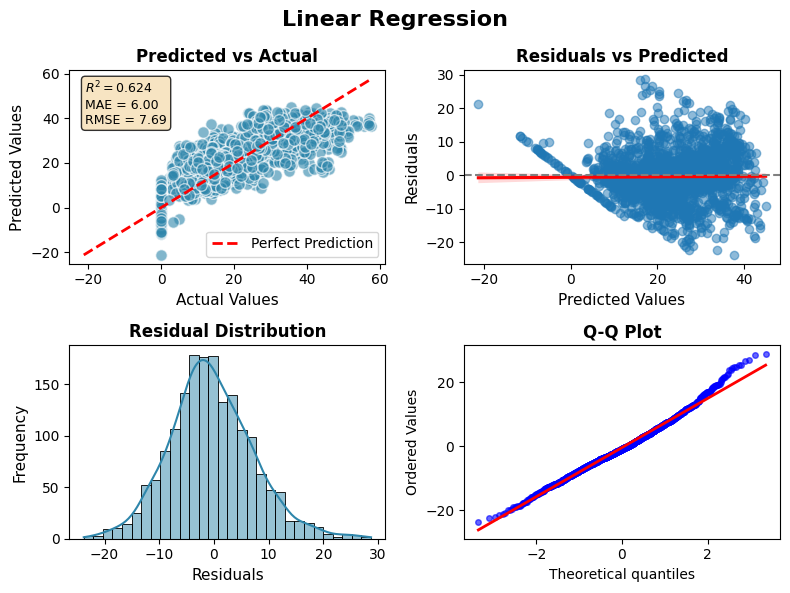

The Mean Absolute Error (MAE) is 6.0007524270426105.
The Mean Squred Error(MSE) is 59.195515202641396.
The Root Mean Squared Error(RMSE) is 7.693862177258012.
The R2 Score is 0.6241226614716798.
Adjusted R2 is 0.6210931377299432.


In [3]:
comparacion.plot_results(y_pred,"Linear Regression")
comparacion.create_entry(y_pred,"Linear Regression",comparacion.comparison_table)


## Lasso

The Mean Absolute Error (MAE) is 6.00200778277552.
The Mean Squred Error(MSE) is 59.191183883238686.
The Root Mean Squared Error(RMSE) is 7.693580693229823.
The R2 Score is 0.6241501643121203.
Adjusted R2 is 0.6211208622397943.


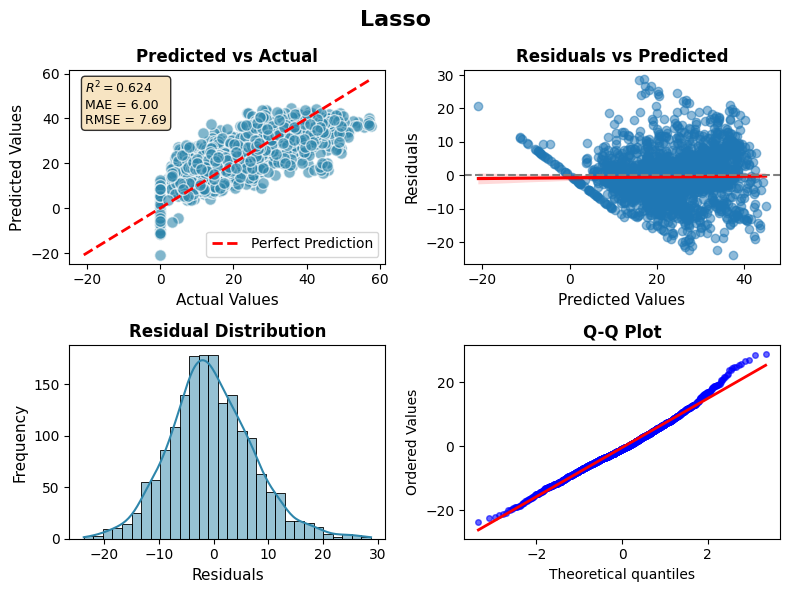

In [4]:
y_pred = comparacion.lasso()
comparacion.create_entry(y_pred,"Lasso",comparacion.comparison_table)

comparacion.plot_results(y_pred,"Lasso")


## Ridge

The Mean Absolute Error (MAE) is 6.000756857581588.
The Mean Squred Error(MSE) is 59.195495226125374.
The Root Mean Squared Error(RMSE) is 7.693860879046707.
The R2 Score is 0.6241227883177702.
Adjusted R2 is 0.6210932655983971.


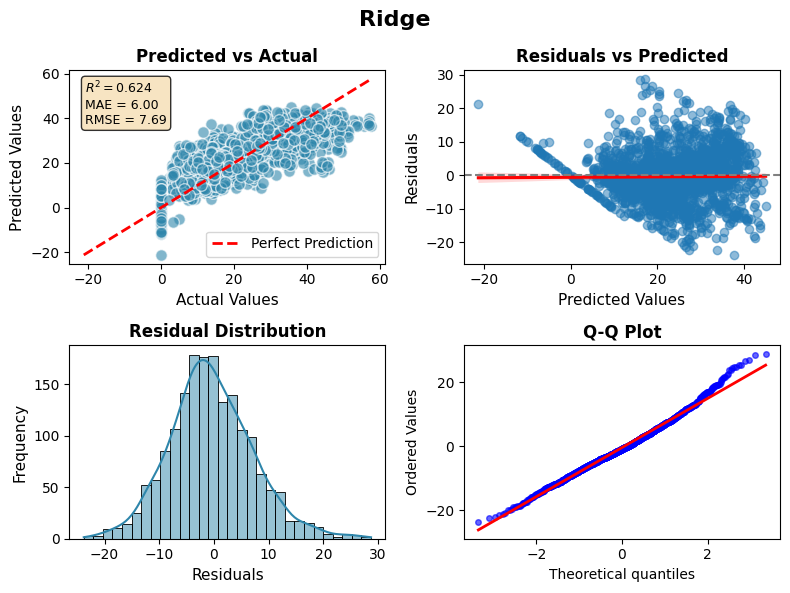

In [5]:
y_pred = comparacion.ridge()
comparacion.create_entry(y_pred,"Ridge",comparacion.comparison_table)

comparacion.plot_results(y_pred,"Ridge")


## Elastic Net

The Mean Absolute Error (MAE) is 6.002905772123643.
The Mean Squred Error(MSE) is 59.198330185352496.
The Root Mean Squared Error(RMSE) is 7.694045111990993.
The R2 Score is 0.624104787005923.
Adjusted R2 is 0.6210751191982563.


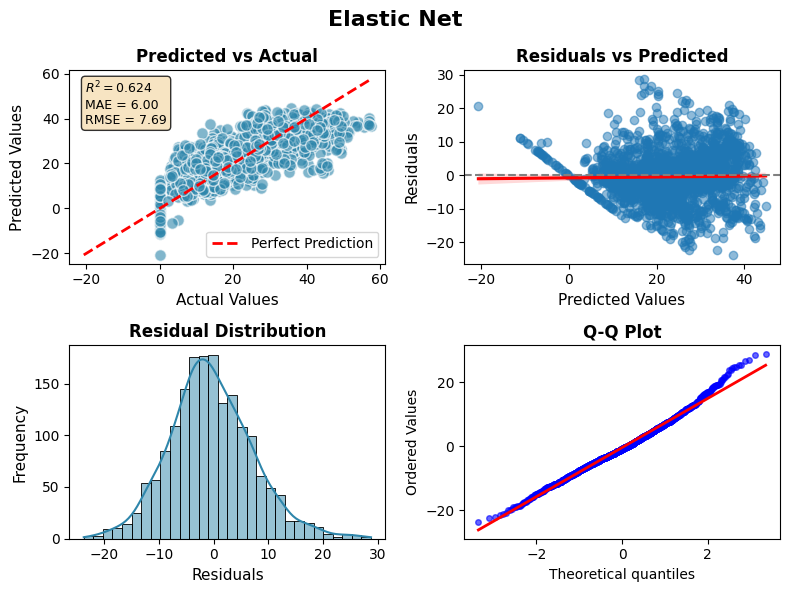

In [6]:
y_pred= comparacion.elastic_net()
comparacion.create_entry(y_pred,"Elastic Net",comparacion.comparison_table)

comparacion.plot_results(y_pred,"Elastic Net")


## Decision Tree

The Mean Absolute Error (MAE) is 3.2909528089737745.
The Mean Squred Error(MSE) is 23.32202914783613.
The Root Mean Squared Error(RMSE) is 4.829288679281467.
The R2 Score is 0.8519107027760544.
Adjusted R2 is 0.850717121796702.


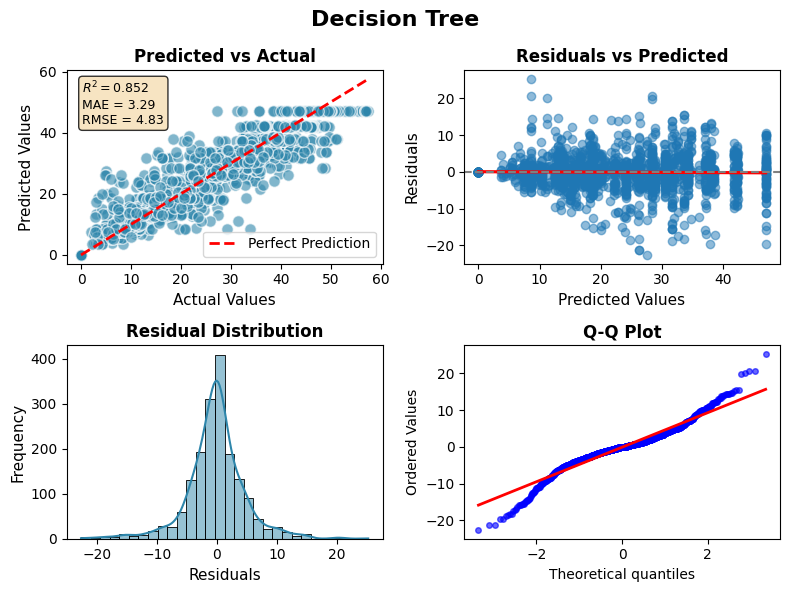

In [7]:
y_pred = comparacion.decision_tree()
comparacion.create_entry(y_pred,"Decision Tree",comparacion.comparison_table)

comparacion.plot_results(y_pred,"Decision Tree")


## Random Forest

The Mean Absolute Error (MAE) is 2.327849072455255.
The Mean Squred Error(MSE) is 12.510304705270485.
The Root Mean Squared Error(RMSE) is 3.5369909111093976.
The R2 Score is 0.9205625625404547.
Adjusted R2 is 0.9199223068556914.


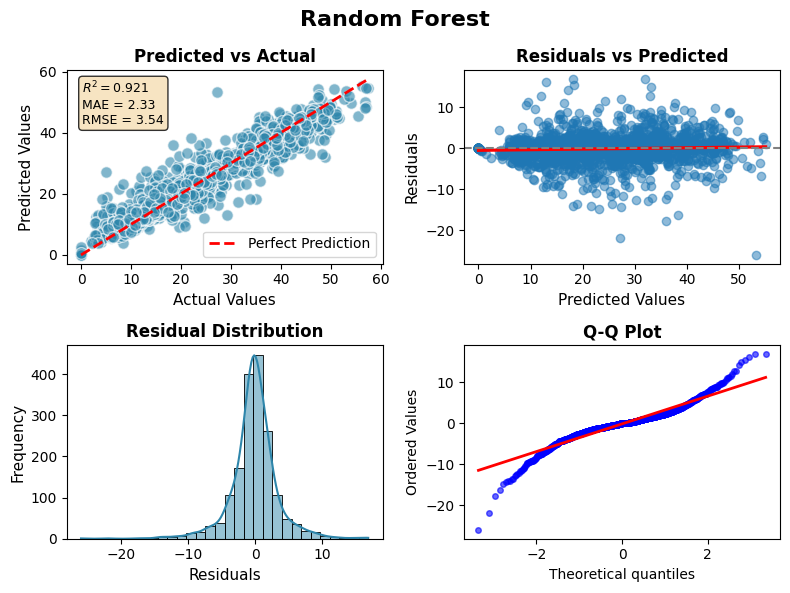

In [8]:
y_pred = comparacion.random_forest()
comparacion.create_entry(y_pred,"Random Forest",comparacion.comparison_table)

comparacion.plot_results(y_pred,"Random Forest")

## Gradient Boosting

The Mean Absolute Error (MAE) is 2.562409807481921.
The Mean Squred Error(MSE) is 14.123760699734872.
The Root Mean Squared Error(RMSE) is 3.758159216921879.
The R2 Score is 0.9103175035532026.
Adjusted R2 is 0.9095946739905917.


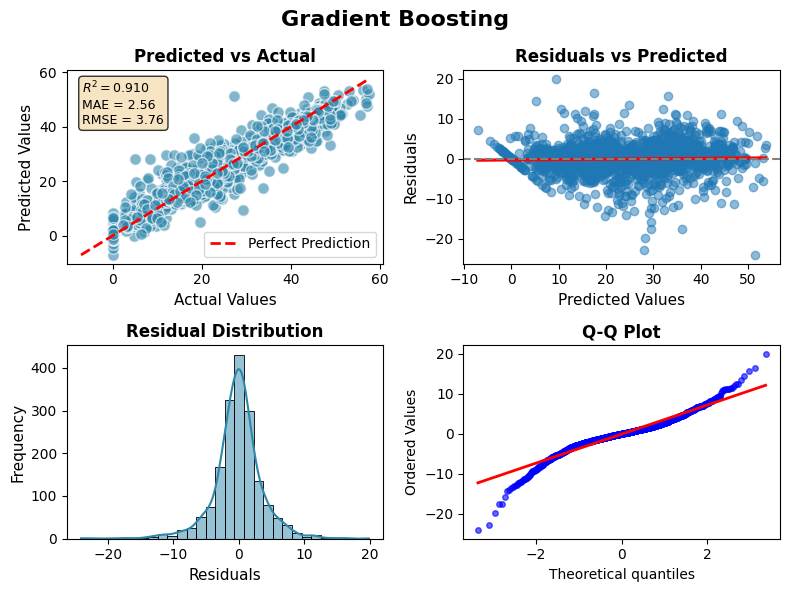

In [9]:
y_pred = comparacion.gradient_boosting()
comparacion.create_entry(y_pred,"Gradient Boosting",comparacion.comparison_table)
comparacion.plot_results(y_pred,"Gradient Boosting")


## Resultados (Sin GridSearchCV)

La siguiente tabla muestra los resultados de los distintos modelos, sin hacer uso de `GridSearchCV`

In [10]:
comparacion.comparison_table

,Model,MAE,MSE,RMSE,R2_score,Adjusted_R2
0,Linear Regression,6.0008,59.1955,7.6939,0.6241,0.6211
1,Lasso,6.0020,59.1912,7.6936,0.6242,0.6211
2,Ridge,6.0008,59.1955,7.6939,0.6241,0.6211
3,Elastic Net,6.0029,59.1983,7.6940,0.6241,0.6211
4,Decision Tree,3.2910,23.3220,4.8293,0.8519,0.8507
5,Random Forest,2.3278,12.5103,3.5370,0.9206,0.9199
6,Gradient Boosting,2.5624,14.1238,3.7582,0.9103,0.9096


Como podemos ver, los mejores modelos resultaron ser `Random Forest` y `Gradient Boosting`. Pero, no hemos optimizado los parámetros aún. Procedemos a usar `GridSearchCV`. La siguiente función buscará los mejores parámetros para todos los modelos, regresara un diccionario con los parámetros para cada modelo. 

In [11]:
best_params = comparacion.grid_searching()

{'lasso': np.float64(0.003906939937054617), 'ridge': np.float64(0.2682695795279725), 'elastic_net': {'alpha': np.float64(0.003906939937054617), 'l1_ratio': np.float64(1.0)}, 'decision_tree': {'max_depth': 11, 'min_samples_leaf': 2, 'min_samples_split': 20}, 'random_forest': {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}, 'gradient_boost': {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}}


Con los parámetros, correremos las predicciones otra vez, deberíamos obtener mejores resultados.

In [12]:
y_predictions = comparacion.re_run_with_better_params()


{'lasso': np.float64(0.003906939937054617), 'ridge': np.float64(0.2682695795279725), 'elastic_net': {'alpha': np.float64(0.003906939937054617), 'l1_ratio': np.float64(1.0)}, 'decision_tree': {'max_depth': 11, 'min_samples_leaf': 2, 'min_samples_split': 20}, 'random_forest': {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}, 'gradient_boost': {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}}
The Mean Absolute Error (MAE) is 6.001146882854267.
The Mean Squred Error(MSE) is 59.19214212651759.
The Root Mean Squared Error(RMSE) is 7.693642968484929.
The R2 Score is 0.6241440796968905.
Adjusted R2 is 0.6211147285833363.
The Mean Absolute Error (MAE) is 6.0008711477817185.
The Mean Squred Error(MSE) is 59.19501699197603.
The Root Mean Squared Error(RMSE) is 7.693829800039512.
The R2 Score is 0.6241258249900357.
Adjusted R2 is 0.6210963267458564.
The Mean Absolute Error (MAE) is 6.001146882854267.
The Mean Squred Error(MSE) is 59.19214212651759.
The Root Mean Squared 

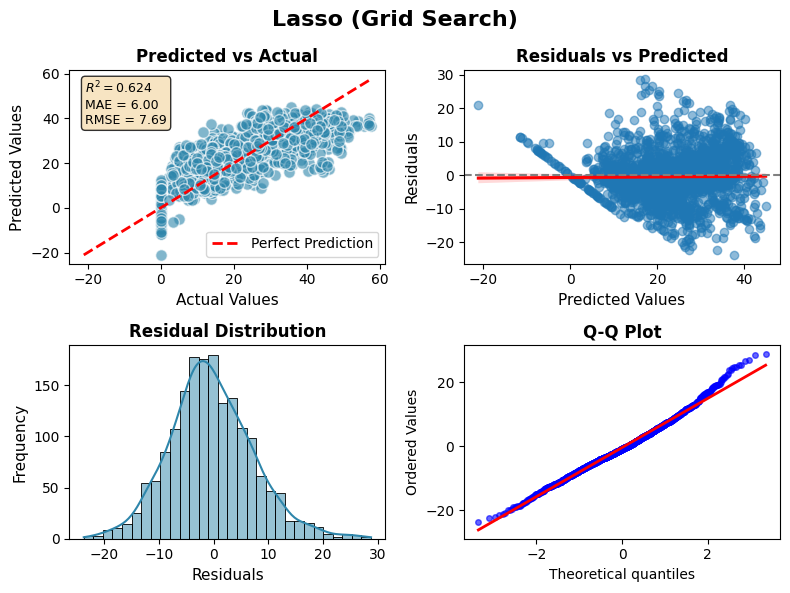

In [13]:
comparacion.plot_results(y_predictions["lasso"],"Lasso (Grid Search)")


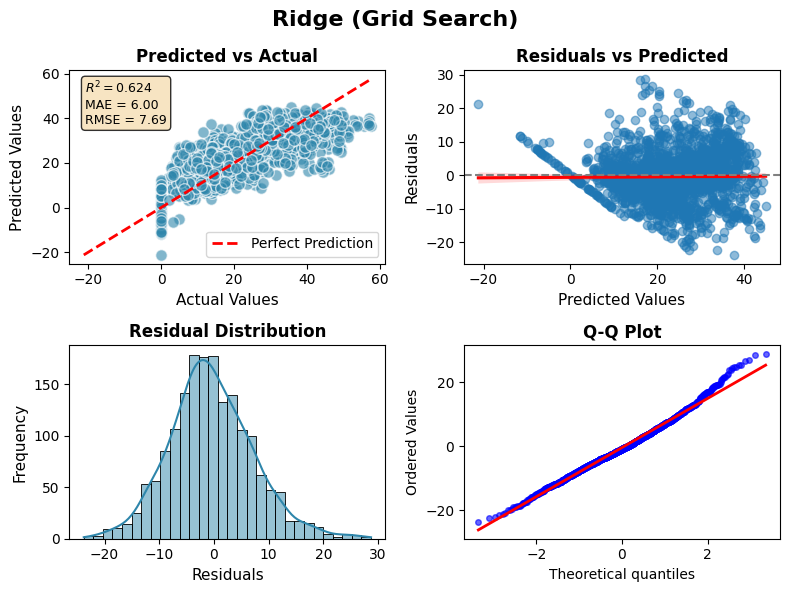

In [14]:
comparacion.plot_results(y_predictions["ridge"],"Ridge (Grid Search)")


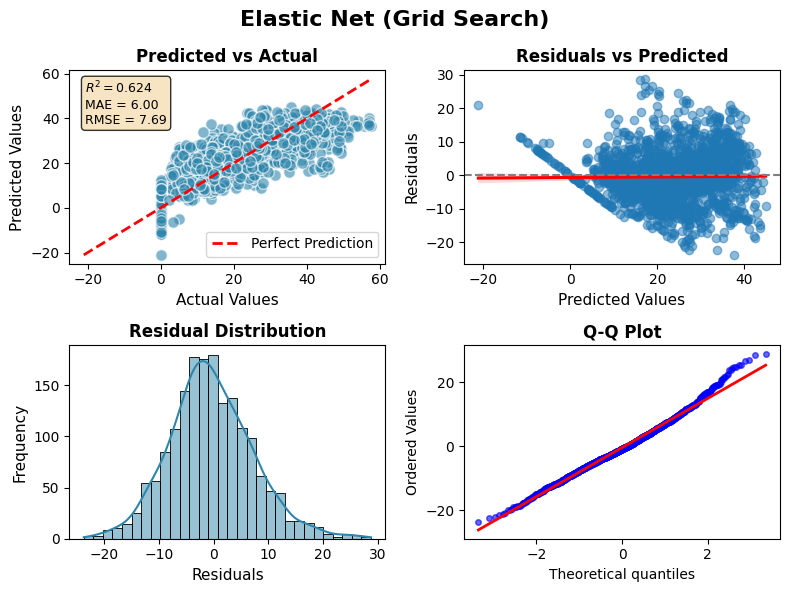

In [15]:
comparacion.plot_results(y_predictions["elastic_net"],"Elastic Net (Grid Search)")


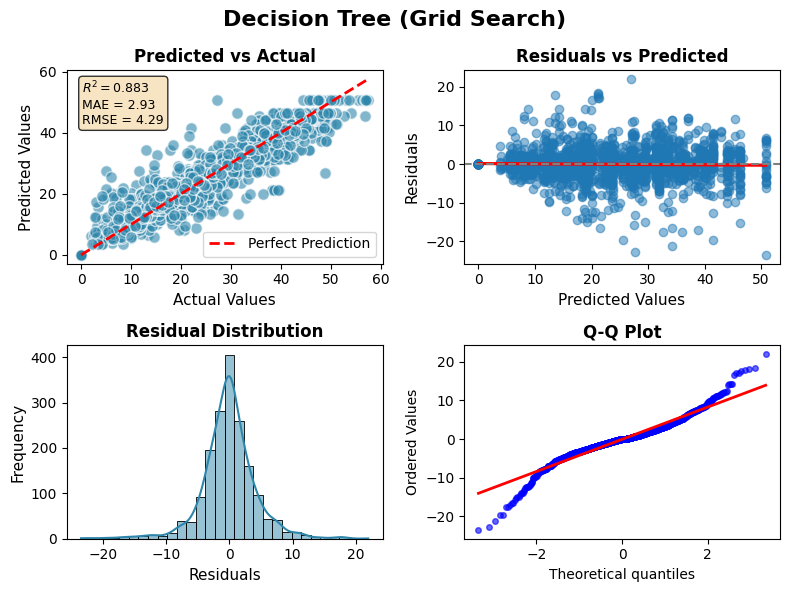

In [16]:
comparacion.plot_results(y_predictions["decision_tree"],"Decision Tree (Grid Search)")


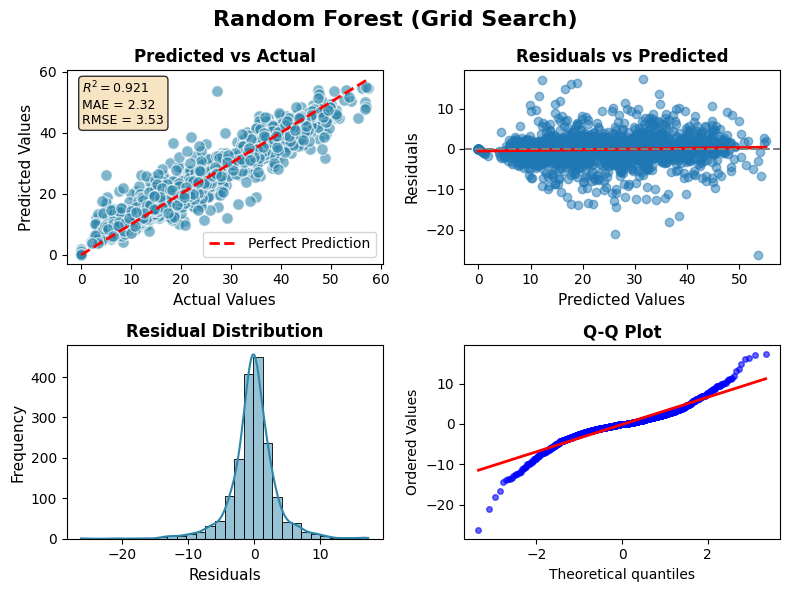

In [17]:
comparacion.plot_results(y_predictions["random_forest"],"Random Forest (Grid Search)")


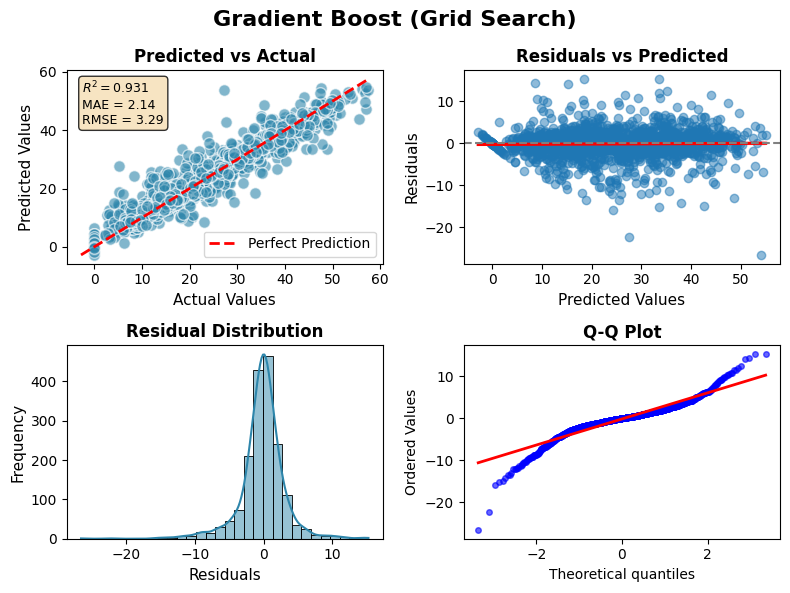

In [18]:
comparacion.plot_results(y_predictions["gradient_boost"],"Gradient Boost (Grid Search)")


## Comparativa de resultados

A continuación, una comparación entre ambas tablas, la primera es con `GridSearchCV`:

In [19]:
comparacion.grid_search_comparison_table

,Model,MAE,MSE,RMSE,R2_score,Adjusted_R2
0,Lasso (Grid Search),6.0011,59.1921,7.6936,0.6241,0.6211
1,Ridge (Grid Search),6.0009,59.1950,7.6938,0.6241,0.6211
2,Elastic Net (Grid Search),6.0011,59.1921,7.6936,0.6241,0.6211
3,Decision Tree (Grid Search),2.9314,18.4147,4.2912,0.8831,0.8821
4,Random Forest (Grid Search),2.3195,12.4299,3.5256,0.9211,0.9204
5,Gradient Boost (Grid Search),2.1359,10.8070,3.2874,0.9314,0.9308


In [20]:
comparacion.comparison_table

,Model,MAE,MSE,RMSE,R2_score,Adjusted_R2
0,Linear Regression,6.0008,59.1955,7.6939,0.6241,0.6211
1,Lasso,6.0020,59.1912,7.6936,0.6242,0.6211
2,Ridge,6.0008,59.1955,7.6939,0.6241,0.6211
3,Elastic Net,6.0029,59.1983,7.6940,0.6241,0.6211
4,Decision Tree,3.2910,23.3220,4.8293,0.8519,0.8507
5,Random Forest,2.3278,12.5103,3.5370,0.9206,0.9199
6,Gradient Boosting,2.5624,14.1238,3.7582,0.9103,0.9096


Podemos notar que el GridSearch sí mejoró los resultados. Random Forest ya era bueno asi que las mejoras fueron pequeñas. Gradient Boosting mejoró significamente. Son estos dos los mejores de todos los modelos usados.Las features con más peso fueron:

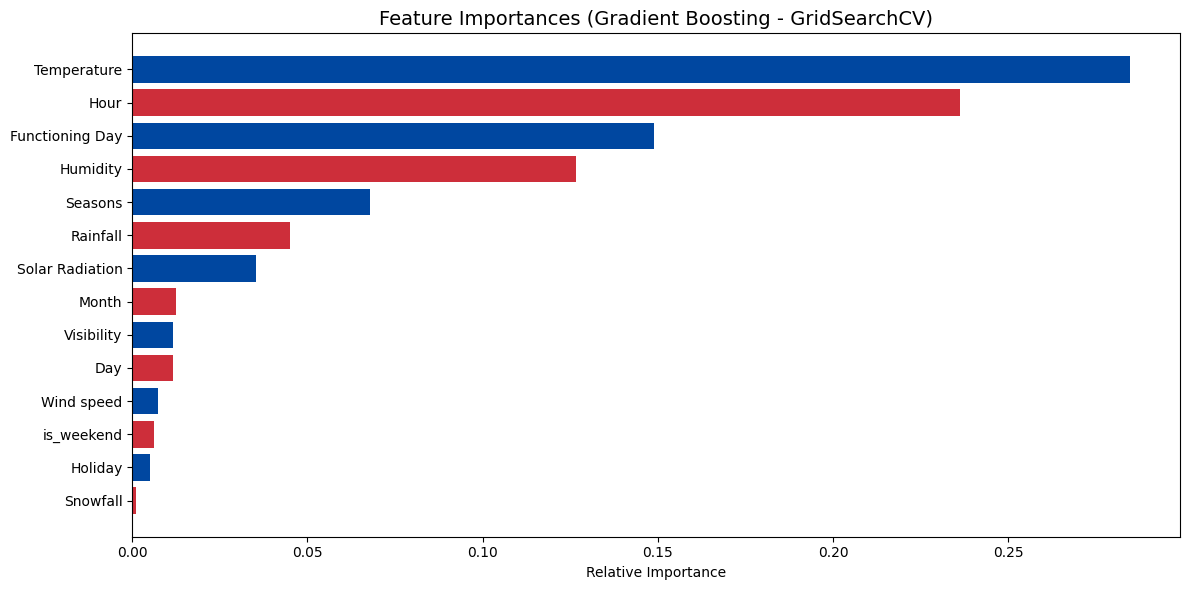

In [21]:
comparacion.most_important_features()